In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from numpy import expand_dims
from numpy import mean
from numpy import ones
from numpy.random import randn
from numpy.random import randint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [38]:
import matplotlib.pyplot as plt

def show_feature_maps(feature_map, num_maps=6):
    feature_map = feature_map.squeeze(0)  # [C, H, W]

    plt.figure(figsize=(15, 5))
    for i in range(num_maps):
        plt.subplot(1, num_maps, i+1)
        plt.imshow(feature_map[i].cpu(), cmap='viridis')
        plt.axis('off')
    plt.show()

In [29]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

204.5576171875 MB


In [30]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # нужно для твоей версии ResNet
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

In [ ]:
train_dataset = datasets.CIFAR10(root=r'C:\MLbrat\andre\MoneyApp\datasets\data_cifar10', train= True, download=True, transform=transform)

test_dataset = datasets.CIFAR10(root=r'C:\MLbrat\andre\MoneyApp\datasets\data_cifar10', train= False, download=True, transform=transform)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=48, shuffle=False)

dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=48, shuffle=True)

c:\Users\semen\AppData\Local\pypoetry\Cache\virtualenvs\priceclassifier-0_d4FkaK-py3.13\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [39]:
fixed_images, fixed_labels = next(iter(dataloader))
fixed_image = fixed_images[0].unsqueeze(0).to(device)
fixed_label = fixed_labels[0].item()

In [32]:
class BasickBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size = 3,
            stride = stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride= 1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        identify = self.shortcut(x)

        out = self.conv1(x)
        out= self.bn1(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.relu(out)

        out = out + identify

        return out


In [33]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super().__init__()

        self.in_channels = 64
        self.conv1 = nn.Conv2d(
            3,64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Linear(512 * block.expansion,num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = []

        layers.append(
            block(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                block(
                    self.in_channels,
                    out_channels
                )
            )

        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x
    

In [34]:
def ResNet18(num_classes=10):
    return ResNet(BasickBlock, [2,2,2,2],num_classes)


In [35]:
model = ResNet18(num_classes=10).to(device)

optimiz = optim.AdamW(model.parameters(),lr = 1e-3)
criterion = nn.CrossEntropyLoss()

epoch = 5

In [40]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

for name, layer in model.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        layer.register_forward_hook(get_activation(name))

In [ ]:
for i in range(epoch):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for image, label in dataloader:
        image = image.to(device)
        label = label.to(device)

        optimiz.zero_grad()

        out = model(image)
        loss = criterion(out, label)
        
        loss.backward()

        optimiz.step()
        running_loss += loss.item()

        _, predicted = out.max(1)

        total += label.size(0)
        correct += predicted.eq(label).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{i+1}/{epoch}] "
        f"Loss: {running_loss/len(dataloader):.4f} "
        f"Acc: {train_acc:.2f}%"
    )

Epoch [6/5] Loss: 1.5790 Acc: 42.12%
Epoch [6/5] Loss: 1.1457 Acc: 58.72%
Epoch [6/5] Loss: 0.9392 Acc: 66.32%
Epoch [6/5] Loss: 0.8093 Acc: 71.36%
Epoch [6/5] Loss: 0.6925 Acc: 75.71%


In [37]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 76.95%


dict_keys(['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2', 'layer2.0.shortcut.0', 'layer2.0.conv1', 'layer2.0.conv2', 'layer2.1.conv1', 'layer2.1.conv2', 'layer3.0.shortcut.0', 'layer3.0.conv1', 'layer3.0.conv2', 'layer3.1.conv1', 'layer3.1.conv2', 'layer4.0.shortcut.0', 'layer4.0.conv1', 'layer4.0.conv2', 'layer4.1.conv1', 'layer4.1.conv2'])


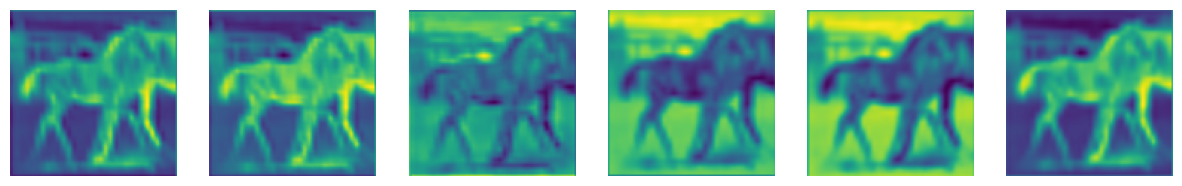

In [ ]:
model.eval()

with torch.no_grad():
    _ = model(fixed_image)   # ← ЭТО ОБЯЗАТЕЛЬНО

print(activations.keys())    # ← проверка
show_feature_maps(activations['conv1'])

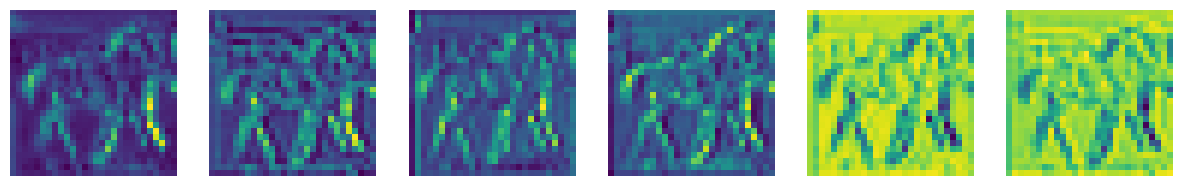

In [54]:
show_feature_maps(activations['layer2.0.shortcut.0'])

In [48]:
print(sum(p.numel() for p in model.parameters()) / 1e6, "M params")

11.181642 M params


In [49]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasickBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
    (1): BasickBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  